# Variational Quantum Deflation (VQD) for $H_2$ Molecule

In this notebook, we demonstrate the ground and excited state energy calculation of the Hydrogen molecule ($H_2$) at various bond distances using the VQD algorithm implemented in our `quantum_chem` module.

In [1]:
import sys
import os
sys.path.append('..') # add the root directory to path

import numpy as np
import matplotlib.pyplot as plt
from quantumchem.hamiltonian import get_h2_hamiltonian
from quantumchem.vqdimlpement import run_vqd_qiskit, run_vqd_pennylane
from quantumchem.visual import plot_potential_energy_surface

## 1. Single Point Calculation at Equilibrium Distance (0.735 Å)

First, we'll run VQD at the equilibrium distance to find the ground and first excited states.

In [2]:
dist = 0.735
qubit_op, problem = get_h2_hamiltonian(dist)
print(f"Qubit operator for H2 at {dist} A:")
print(qubit_op)

# Run VQD with Qiskit for 2 states
energies_qiskit, _ = run_vqd_qiskit(qubit_op, num_states=2)
print(f"Qiskit VQD Energies (Hartree): Ground={energies_qiskit[0]:.4f}, 1st Excited={energies_qiskit[1]:.4f}")

Qubit operator for H2 at 0.735 A:
SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.81054798+0.j,  0.17218393+0.j, -0.22575349+0.j,  0.17218393+0.j,
 -0.22575349+0.j,  0.12091263+0.j,  0.16892754+0.j,  0.16614543+0.j,
  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,
  0.16614543+0.j,  0.17464343+0.j,  0.12091263+0.j])
Qiskit VQD Energies (Hartree): Ground=-1.8573, 1st Excited=-1.2001


## 2. Potential Energy Surface (PES)

Now we'll calculate the ground and excited states for a range of distances to map the Potential Energy Surface.

Calculating for distance: 0.20 A...
Calculating for distance: 0.46 A...
Calculating for distance: 0.71 A...
Calculating for distance: 0.97 A...
Calculating for distance: 1.22 A...
Calculating for distance: 1.48 A...
Calculating for distance: 1.73 A...
Calculating for distance: 1.99 A...
Calculating for distance: 2.24 A...
Calculating for distance: 2.50 A...


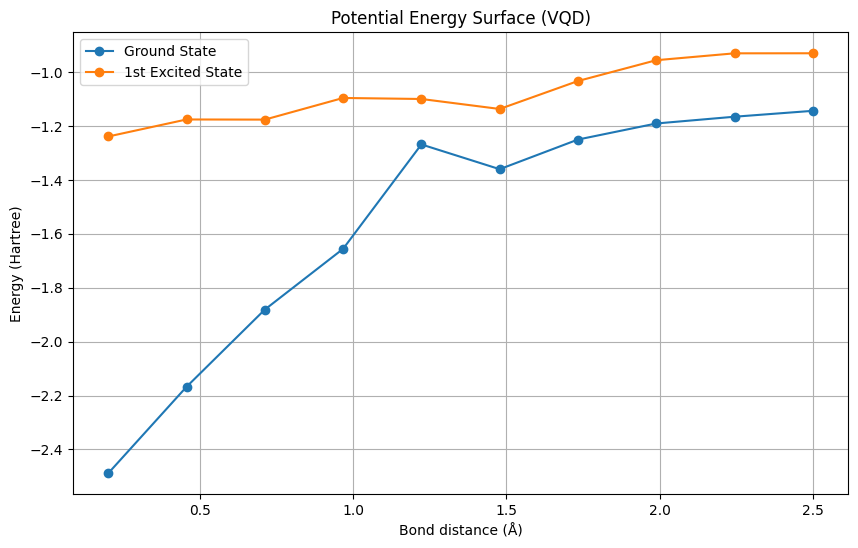

In [3]:
distances = np.linspace(0.2, 2.5, 10)
ground_energies = []
excited_energies = []

for dist in distances:
    print(f"Calculating for distance: {dist:.2f} A...")
    qubit_op, problem = get_h2_hamiltonian(dist)
    energies, _ = run_vqd_qiskit(qubit_op, num_states=2)
    ground_energies.append(energies[0])
    excited_energies.append(energies[1])

pes_data = {
    "Ground State": ground_energies,
    "1st Excited State": excited_energies
}

plot_potential_energy_surface(distances, pes_data)

## 3. Comparison with PennyLane Implementation

Let's compare the results with the PennyLane-based VQD implementation at a single point.

In [4]:
dist = 0.735
qubit_op, _ = get_h2_hamiltonian(dist)
energies_pennylane, _ = run_vqd_pennylane(qubit_op, num_states=2)
print(f"PennyLane VQD Energies (Hartree): Ground={energies_pennylane[0]:.4f}, 1st Excited={energies_pennylane[1]:.4f}")

PennyLane VQD Energies (Hartree): Ground=-1.1816, 1st Excited=-1.1349
